In [4]:
from pymongo import MongoClient

#HOST="(...).mongodb.net"
HOST="cluster0.nl8aj.mongodb.net"
PORT=27017
USERNAME="madalinismana365"
PASSWORD="Madalin13245678..."

if HOST == 'localhost':
    if not USERNAME:
        cli_mongo = MongoClient(HOST, PORT)
    else:
        cli_mongo = MongoClient(HOST, PORT, USERNAME, PASSWORD)
else:
    cli_mongo = MongoClient(f"mongodb+srv://{USERNAME}:{PASSWORD}@{HOST}/test")

print (cli_mongo.list_database_names())
##usar la base de covid
db_covid=cli_mongo['covid']
#usar la coleccion de coviditalia
db_coviditalia=db_covid['coviditalia']

['Estudantes2', 'PruebaClase', 'RickyMorty', 'covid', 'sample_mflix', 'sample_restaurants', 'sample_supplies', 'admin', 'local']


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
##Pon unha variable en función da cal se lea de mongo ou se empregue o read_json() para ler o dataset dun arquivo no seu lugar.
##df=pd.read_json('coviditalia.json')
df=pd.DataFrame(list(db_coviditalia.find()))

In [17]:
df.head(5)

,_id,data,stato,codice_regione,denominazione_regione,codice_provincia,denominazione_provincia,sigla_provincia,lat,long,totale_casi,note,codice_nuts_1,codice_nuts_2,codice_nuts_3
0,67dc7c48e0577331e8f40a50,2020-02-24T18:00:00,ITA,13,Abruzzo,66,L'Aquila,AQ,42.351222,13.398438,1,None,None,None,None
1,67dc7c48e0577331e8f40a51,2020-02-24T18:00:00,ITA,13,Abruzzo,67,Teramo,TE,42.658918,13.704400,0,None,None,None,None
2,67dc7c48e0577331e8f40a52,2020-02-24T18:00:00,ITA,13,Abruzzo,68,Pescara,PE,42.464584,14.213648,0,None,None,None,None
3,67dc7c48e0577331e8f40a53,2020-02-24T18:00:00,ITA,13,Abruzzo,69,Chieti,CH,42.351032,14.167546,0,None,None,None,None
4,67dc7c48e0577331e8f40a54,2020-02-24T18:00:00,ITA,13,Abruzzo,979,In fase di definizione/aggiornamento,None,NaN,NaN,0,None,None,None,None


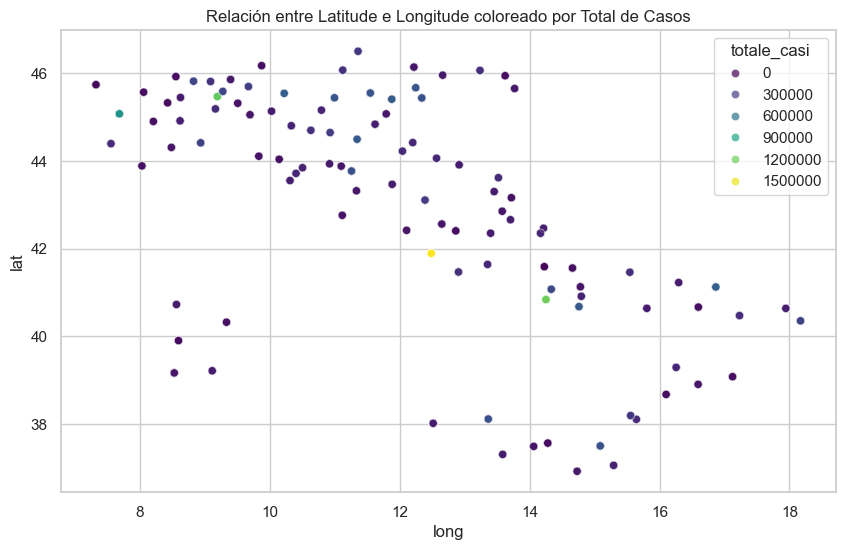

C:\Users\constantin.madalin.i\AppData\Local\Temp\ipykernel_21576\1489685591.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='denominazione_regione', y='totale_casi', ci=None, estimator=np.mean, palette='coolwarm')
C:\Users\constantin.madalin.i\AppData\Local\Temp\ipykernel_21576\1489685591.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='denominazione_regione', y='totale_casi', ci=None, estimator=np.mean, palette='coolwarm')


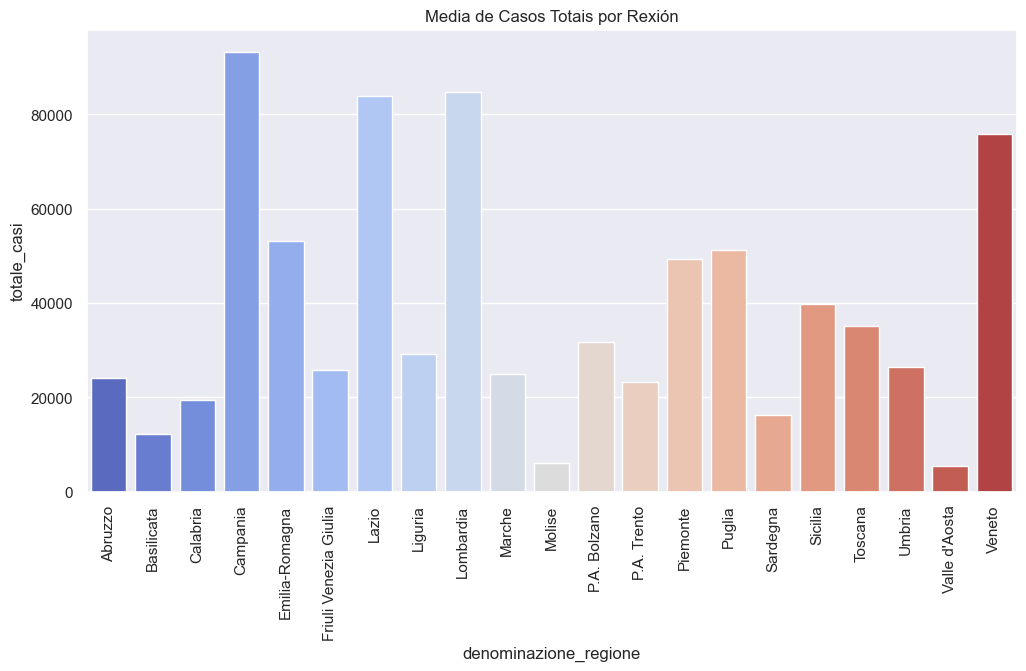

C:\Users\constantin.madalin.i\AppData\Local\Temp\ipykernel_21576\1489685591.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='denominazione_regione', y='totale_casi', palette='Set3')


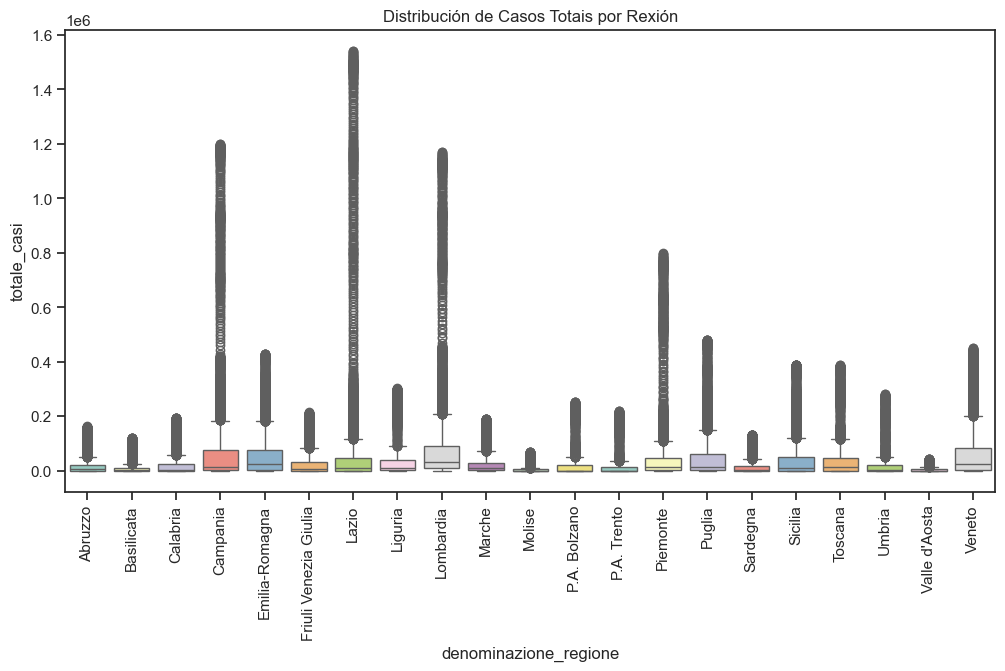

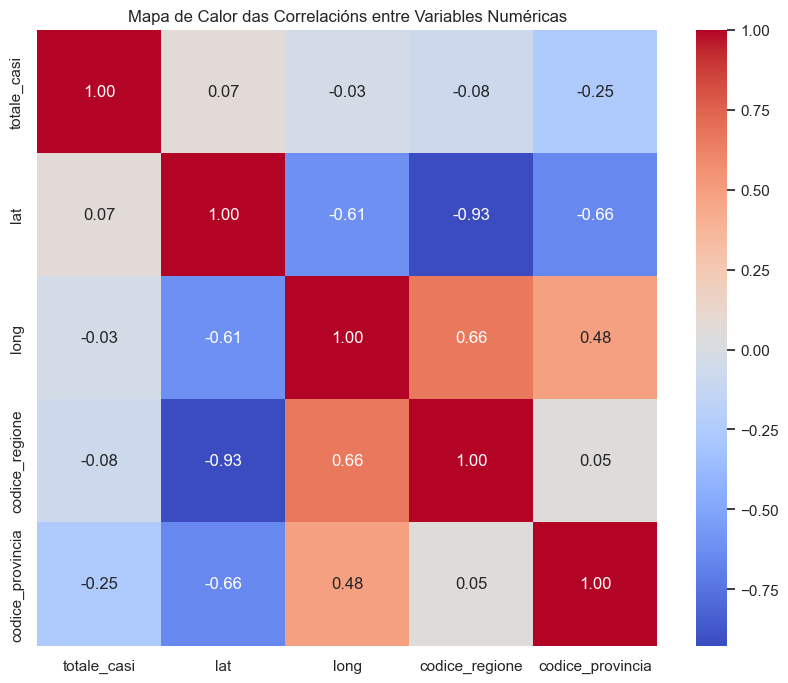

In [6]:
# Gráfico 1: Scatterplot (relación entre latitude e longitude, coloreado por total de casos)
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.scatterplot(data=df, x='long', y='lat', hue='totale_casi', palette='viridis', alpha=0.7)
plt.title('Relación entre Latitude e Longitude coloreado por Total de Casos')
plt.show()

# Gráfico 2: Barplot (media de casos totais por rexión)
plt.figure(figsize=(12, 6))
sns.set_theme(style="darkgrid")
sns.barplot(data=df, x='denominazione_regione', y='totale_casi', ci=None, estimator=np.mean, palette='coolwarm')
plt.xticks(rotation=90)
plt.title('Media de Casos Totais por Rexión')
plt.show()

# Gráfico 3: Boxplot (distribución de casos totais por rexión)
plt.figure(figsize=(12, 6))
sns.set_theme(style="ticks")
sns.boxplot(data=df, x='denominazione_regione', y='totale_casi', palette='Set3')
plt.xticks(rotation=90)
plt.title('Distribución de Casos Totais por Rexión')
plt.show()

# Gráfico 4: Heatmap (correlación entre variables numéricas)
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")
correlation_matrix = df[['totale_casi', 'lat', 'long', 'codice_regione', 'codice_provincia']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Calor das Correlacións entre Variables Numéricas')
plt.show()